# Nucleosome deposition for Late replicating genes

Show how nucleosomes deposit differently depending on pre-S and post-S transcription.

### Procedure:
1. Identify late replicating genes
2. Segment by peak transcription phase


In [7]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

outdir = "output/deconvolved_genome_g0066_offset1_10k_10x10_2024_10_11/"
analysis = GenomeDeconvolutionAnalysis(outdir)

In [434]:
outdir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/'
analysis.load_gene_expression(outdir)

In [435]:
analysis.select_cg1_g2m_genes(0.05)

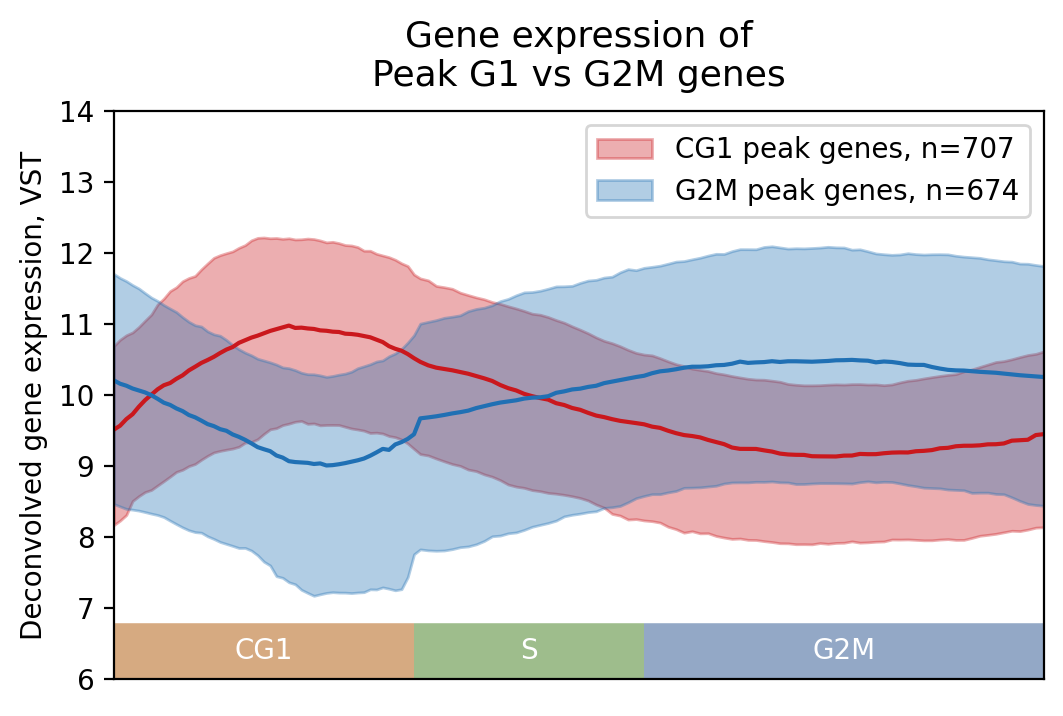

In [523]:
from src.timecourse_plotter import TimecoursePlotter

tc_plotter = TimecoursePlotter(analysis.config)
tc_plotter.plot_timecourse(analysis.deconvolved_gene_expression_t,
    cg1_genes, g2m_genes, f"Gene expression of\nPeak G1 vs G2M genes", 
    "CG1 peak genes", "G2M peak genes", ylim=(6, 14), 
                           ylabel="Deconvolved gene expression, VST")

save_figure_for_paper('output/figures/Expression_Chromatin/CG1_G2M_Gene_Expression.png')


In [132]:
# fig = analysis.plot_tss_pas_chrom(gene_clustering.gene_expression.loc[cg1_genes], 
#     title=f"CG1 genes, n={len(cg1_genes)}")


In [133]:
# fig = analysis.plot_tss_pas_chrom(gene_clustering.gene_expression.loc[g2m_genes], 
#     title=f"G2M genes, n={len(g2m_genes)}")


In [107]:
# Retrieve the occupancy values for all genes, combine TSS and PAS values
# Plot G1 peak genes and G2M peak genes as a time course separating early 
# and late replicating genes as well as a scatter plot.
#
# Does the story mimic the buffering/non-buffering story for
# G2M/G1 peak genes?
#
# i.e. Genes that peak in G1 (non-buffering) show a greater drop in nucleosome 
#      occupancy when late replicating

# Retrieve occupancy values for genes
_, all_occ_TSS = analysis.load_stacked_mnase_data_for_genes(
    gene_clustering.gene_expression[[]], compute_gb_occ=True, center_mode='+1')

_, all_occ_PAS = analysis.load_stacked_mnase_data_for_genes(
   gene_clustering.gene_expression[[]], compute_gb_occ=True, center_mode='PAS_nuc')

all_mnase_occ = all_occ_TSS+all_occ_PAS

200/5578 - 00:00:27.673
400/5578 - 00:00:54.789
600/5578 - 00:01:21.992
800/5578 - 00:01:49.111
1000/5578 - 00:02:16.769
1200/5578 - 00:02:44.715
1400/5578 - 00:03:12.198
1600/5578 - 00:03:39.663
1800/5578 - 00:04:06.922
2000/5578 - 00:04:34.695
2200/5578 - 00:05:01.885
2400/5578 - 00:05:29.185
2600/5578 - 00:05:56.475
2800/5578 - 00:06:23.690
3000/5578 - 00:06:53.681
3200/5578 - 00:07:22.188
3400/5578 - 00:07:51.645
3600/5578 - 00:08:20.160
3800/5578 - 00:08:47.972
4000/5578 - 00:09:16.116
4200/5578 - 00:09:44.368
4400/5578 - 00:10:12.684
4600/5578 - 00:10:39.871
4800/5578 - 00:11:07.103
5000/5578 - 00:11:34.298
5200/5578 - 00:12:01.586
5400/5578 - 00:12:29.549
200/5578 - 00:00:27.774
400/5578 - 00:00:57.578
600/5578 - 00:01:25.931
800/5578 - 00:01:54.348
1000/5578 - 00:02:22.455
1200/5578 - 00:02:53.670
1400/5578 - 00:03:24.629
1600/5578 - 00:03:54.157
1800/5578 - 00:04:23.372
2000/5578 - 00:04:52.275
2200/5578 - 00:05:20.407
2400/5578 - 00:05:48.190
2600/5578 - 00:06:15.349
2800/557

In [84]:
# Plot the scatter plots that depict the occupancy at S and G2M for G1 and G2M genes
# labeling by replication timing

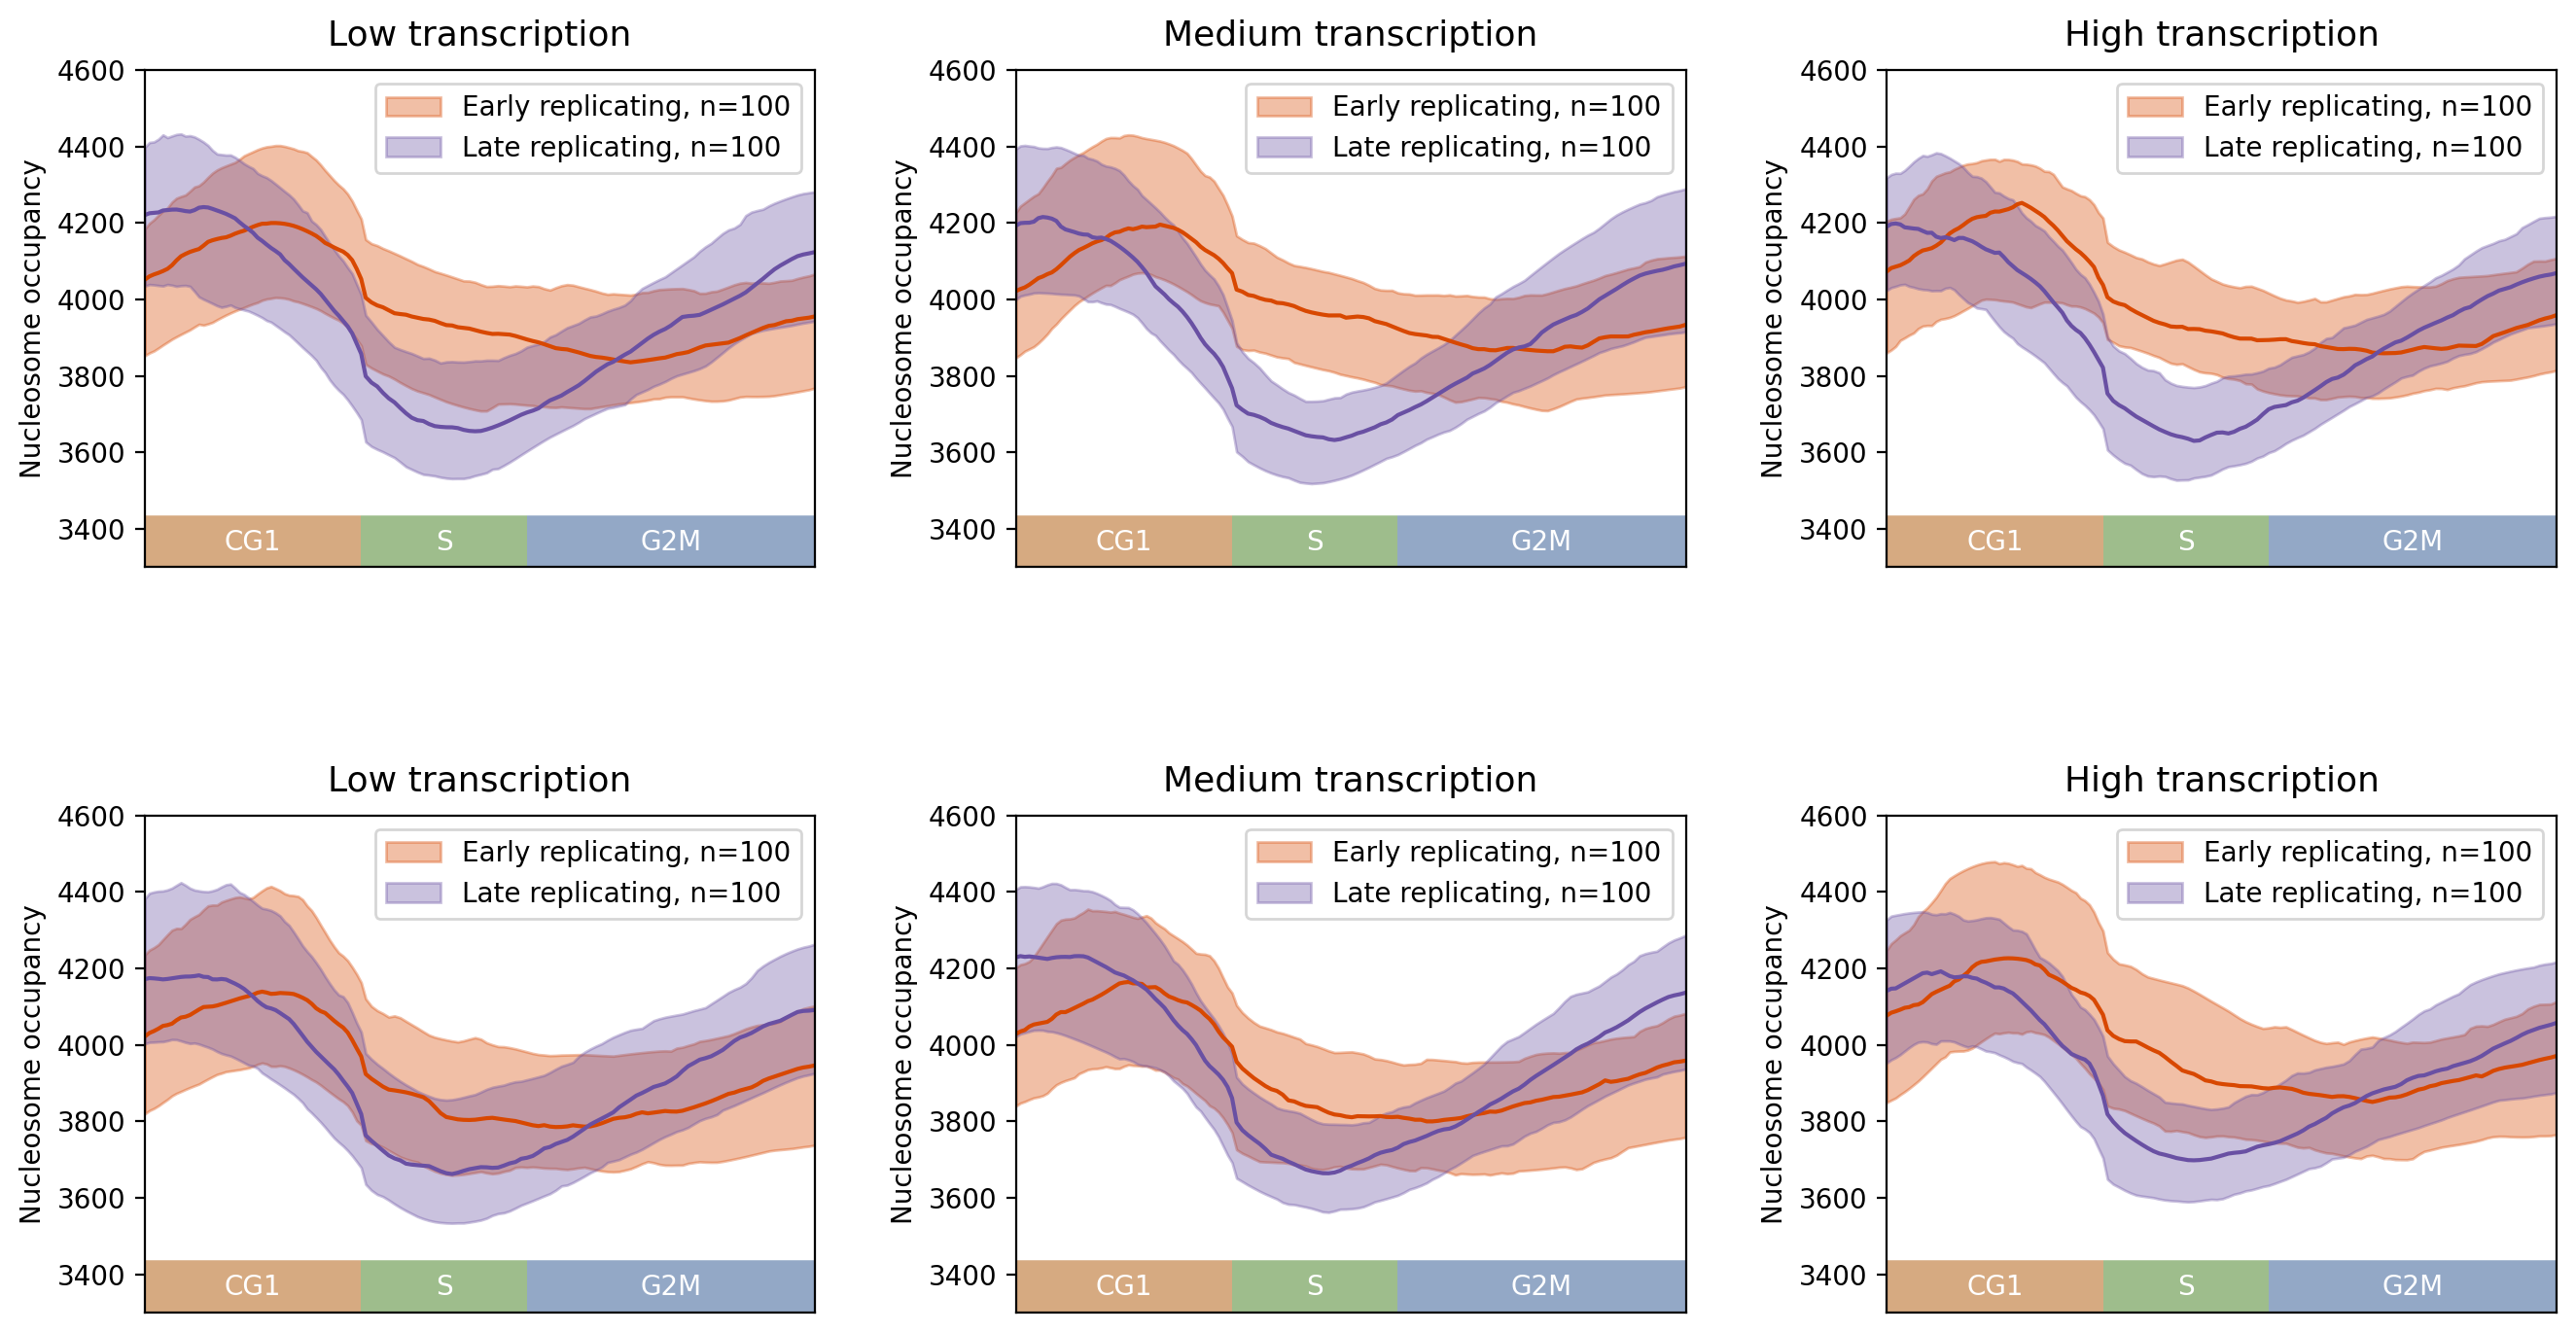

In [522]:
from src.timecourse_plotter import TimecoursePlotter
from src.calcH_single_g1 import get_quantile_values
from src.nucleosome_transription_story import plot_quantile_levels

low_color = plt.get_cmap('Oranges')(0.75)
high_color = plt.get_cmap('Purples')(0.75)
        
tc_plotter = TimecoursePlotter(analysis.config)
tc_plotter.color_1 = low_color
tc_plotter.color_2 = high_color

gene_sets = [cg1_genes, g2m_genes]

k = 3

fig = plt.figure(figsize=(16, 9))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
tx_labels = ["Low", "Medium", "High"]

for j in range(len(gene_sets)):
    gene_tx_means = deconvolved_gene_expression_t.loc[gene_sets[j]].mean(axis=1)

    segments, qvals, lengths = get_quantile_values(
        gene_tx_means, np.linspace(0, 1, k+1)[1:-1])

    for i in range(len(segments)):
        segment = segments[i]

        plt.subplot(2, 3, j*3+(i+1))

        early_genes = genes_replication.loc[segment.index].sort_values(
            'replication_time').head(100).index
        late_genes = genes_replication.loc[segment.index].sort_values(
            'replication_time').tail(100).index

        tc_plotter.plot_timecourse(all_mnase_occ,
            early_genes, late_genes, 
            f"{tx_labels[i]} transcription", 
            "Early replicating", "Late replicating", 
            ylim=(3300, 4600), 
            ylabel="Nucleosome occupancy", fig=fig)

from src.figure_configs import save_figure_for_paper

save_figure_for_paper('output/figures/Expression_Chromatin/Low_Med_High_CG1_G2M_Nucleosome_occupancy.png')
